In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('Age_Salary_Buy.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(dataset.iloc[:10, :])
X[:,1] = X[:,1]/1000
print(X[:10,:])

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
5   27            58000          0
6   27            84000          0
7   32           150000          1
8   25            33000          0
9   35            65000          0
[[ 19  19]
 [ 35  20]
 [ 26  43]
 [ 27  57]
 [ 19  76]
 [ 27  58]
 [ 27  84]
 [ 32 150]
 [ 25  33]
 [ 35  65]]


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
# Keep copies for plotting
X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

In [5]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# Compute the means and standard deviations of features w.r.t
# training set. Transform X_train
X_train = sc.fit_transform(X_train)

# Using the scaler computed above, transform X_test
X_test = sc.transform(X_test)

In [7]:
print(X_train[:10,:])

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]]


In [8]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        
        self._backward = lambda: None
        self._prev = set(_children)        

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        out = Value(np.tanh(self.data), (self,))

        def _backward():
            self.grad += (1-out.data**2) * out.grad
        out._backward = _backward

        return out


    def log(self):
        eps = 1e-15
        x = np.clip(self.data, eps, 1 - eps)
        out = Value(np.log(x), (self,))
        def _backward():
            # derivative uses clamped x to avoid 1/0
            self.grad += (1/x) * out.grad
        out._backward = _backward
        return out


    def sig(self):
        out = Value(1.0/(1+np.exp(-self.data)), (self,))

        def _backward():
            self.grad += out.data*(1-out.data) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


In [9]:
import random

# Activation helpers that operate on a single Value
def act_identity(v): 
    return v

def act_relu(v):
    return v.relu()

def act_tanh(v):
    return v.tanh()

def act_sigmoid(v):
    return v.sig()

class Neuron:

    def __init__(self, nin, activation=act_sigmoid):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)        
        self.activation = activation

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return self.activation(act)

    def parameters(self):
        return self.w + [self.b]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Linear Neuron({len(self.w)})"

class Layer:

    def __init__(self, nin, nout, activation=act_sigmoid):
        self.neurons = [Neuron(nin, activation=activation) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"Layer"

class MLP:

    def __init__(self, nin, nouts, activations):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], activation=activations[i]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    
    def __repr__(self):
        return f"MLP"

In [10]:
    def log_loss(y, p):
        losses = [-pi.log()*yi - (-pi+1).log()*(1-yi) for pi, yi in zip(p,y)]
        loss = sum(losses)/len(losses)
        return loss

In [11]:
mlp = MLP(2,[4,1],[act_relu,act_sigmoid])
etha = 0.05
print(len(mlp.parameters()))

17


In [45]:
batch_size = 32
n_samples = X_train.shape[0]

for epoch in range(500):
    # Shuffle data at the start of each epoch
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # Loop over batches
    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        Xb = X_shuffled[start:end]
        yb = y_shuffled[start:end]

        # Forward pass
        ypred = [mlp(x) for x in Xb]
        loss = log_loss(yb, ypred)

        # Backward pass
        mlp.zero_grad()
        loss.backward()

        # Update
        for p in mlp.parameters():
            p.data -= etha * p.grad

    if epoch%10 == 0: print(epoch, loss.data)

0 0.45509789885940194
10 0.26175279044078587
20 0.15799458470698674
30 0.29456437731611623
40 0.4064542009863237
50 0.19920766611587096
60 0.4316004412902788
70 0.27262069241980835
80 0.33065718754189616
90 0.1795639229677453
100 0.0805015984300834
110 0.06322249773179767
120 0.06902288622543697
130 0.24881466937212648
140 0.27777250010519433
150 0.36720853136072784
160 0.09262695851344079
170 0.058146788429682274
180 0.059868824763880585
190 0.4171215035473235
200 0.3711658975012109
210 0.21972499124921643
220 0.34895209692564594
230 0.18291618358987574
240 0.4292462002539722
250 0.25681183541178765
260 0.13841151883486646
270 0.3635039929938782
280 0.44077661633671483
290 0.31148944491134034
300 0.21826660211823545
310 0.18143900530978918
320 0.14248590694388485
330 0.3760132375695331
340 0.24266944560774997
350 0.2725400981309749
360 0.40488287876222284
370 0.09359949667184148
380 0.2921282042396591
390 0.2404845485700941
400 0.20996222825606406
410 0.2483891554347866
420 0.17195989

In [23]:
def predict_proba_mlp(model, X_scaled):
    """Return probabilities (numpy array) for X_scaled using micrograd MLP."""
    probs = []
    for x in X_scaled:
        out = model(x)                 # out is a Value
        probs.append(float(out.data))  # extract scalar
    return np.array(probs)

In [24]:
def predict_mlp(model, X_scaled):
    yprob = predict_proba_mlp(model, X_scaled)
    y_zero_one = [1 if i>=0.5 else 0 for i in yprob]
    return np.array(y_zero_one)

In [64]:
y_pred = predict_mlp(mlp, X_train)

In [65]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print(cm)
print(accuracy_score(y_train, y_pred))

[[173  16]
 [ 13  98]]
0.9033333333333333


In [66]:
y_pred_test = predict_mlp(mlp, X_test)

In [67]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(accuracy_score(y_test, y_pred_test))

[[64  4]
 [ 5 27]]
0.91


In [68]:
print(X_train_orig[:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


In [69]:
X_set= X_train_orig
#X_set[:,1] = X_set[:,1]/1000
print(X_set[0:10,:])

[[ 44  39]
 [ 32 120]
 [ 38  50]
 [ 32 135]
 [ 52  21]
 [ 53 104]
 [ 39  42]
 [ 38  61]
 [ 36  50]
 [ 36  63]]


(14.0, 150.75)

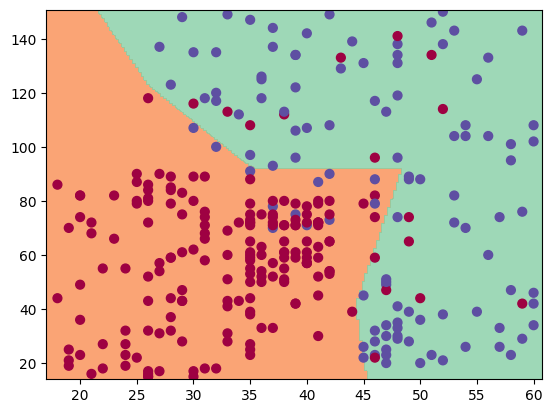

In [39]:
h = 0.25
x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
Xmesh = sc.transform(Xmesh)
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(mlp, inputs))
Z = np.array([s.data >= 0.5 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_train, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())